In [29]:
from google.colab import files

uploaded = files.upload()

Saving blibli_reviews.csv to blibli_reviews (1).csv


# Analisis Sentimen Review Aplikasi Blibli Menggunakan Support Vector Machine (SVM)

In [30]:
import pandas as pd

In [31]:
df = pd.read_csv('blibli_reviews.csv')

## 1. Pengumpulan dan Pembacaan Dataset

In [32]:
df = df[['content', 'score']]

df.head()

,content,score
0,bagus sekali wort it lah pelayanan baik bah,1
1,pihak ekspedisi dan csnya problematik,1
2,"Mengecewakan. Limit selalu diblokir, tidak ada...",1
3,apk sampah buka aja lemot padahal jaringan bag...,1
4,apk gk jelas memberikan penawaran casback namu...,1


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  1200 non-null   object
 1   score    1200 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 18.9+ KB


## 2. Labeling Sentimen

In [34]:
def sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

df['sentiment'] = df['score'].apply(sentiment)

In [35]:
df['sentiment'].value_counts()

,count
sentiment,
Negatif,400
Netral,400
Positif,400


In [36]:
!pip install nltk wordcloud

In [37]:
import re
import nltk

from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [38]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set(stopwords.words('indonesian'))

## 3. Text Preprocessing
Tahapan preprocessing meliputi:
- Case Folding
- Cleaning
- Stopword Removal

In [39]:
import re

def preprocess(text):
    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

In [40]:
df['clean_text'] = df['content'].apply(preprocess)

In [41]:
df[['content', 'clean_text']].head()

,content,clean_text
0,bagus sekali wort it lah pelayanan baik bah,bagus wort it pelayanan bah
1,pihak ekspedisi dan csnya problematik,ekspedisi csnya problematik
2,"Mengecewakan. Limit selalu diblokir, tidak ada...",mengecewakan limit diblokir penjelasan transak...
3,apk sampah buka aja lemot padahal jaringan bag...,apk sampah buka aja lemot jaringan bagus ku te...
4,apk gk jelas memberikan penawaran casback namu...,apk gk penawaran casback casback kunjung terima


## 4. Distribusi Sentimen

In [42]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()



## 5. Visualisasi Sentimen

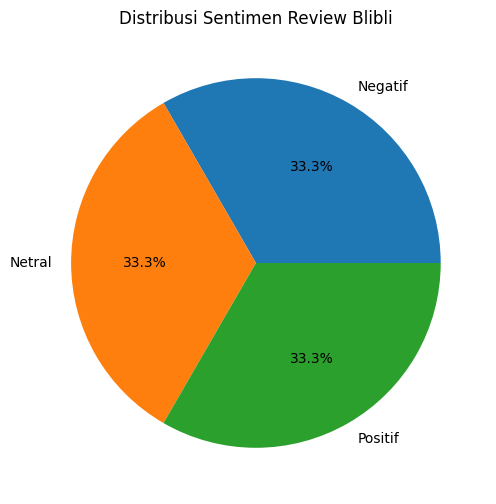

In [43]:
plt.figure(figsize=(6,6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribusi Sentimen Review Blibli')
plt.show()

### 5.1 WordCloud Sentimen Positif

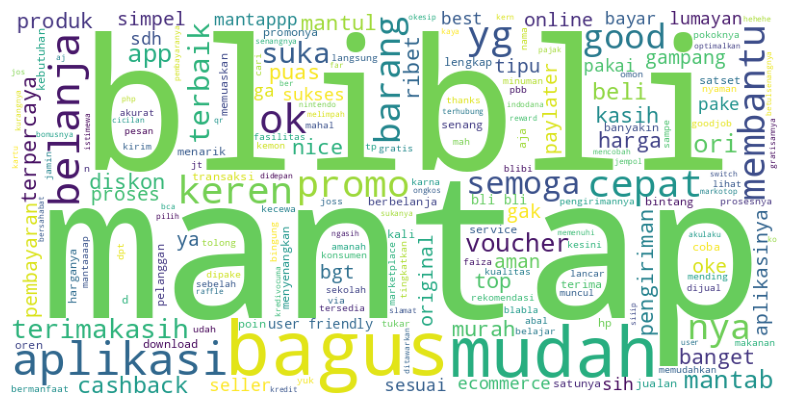

In [44]:


# WordCloud Positif
from wordcloud import WordCloud

positive_text = " ".join(
    df[df['sentiment']=='Positif']['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


### 5.2 WordCloud Sentimen Negatif

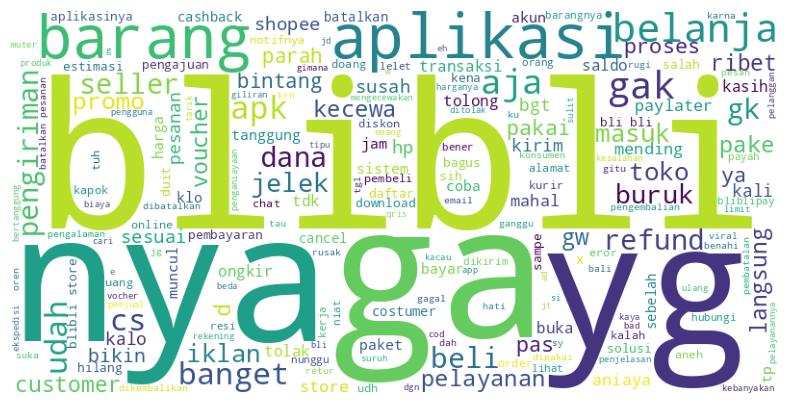

In [45]:
# WordCloud Negatif
negative_text = " ".join(
    df[df['sentiment']=='Negatif']['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## 6. Ekstraksi Fitur Menggunakan TF-IDF
TF-IDF digunakan untuk mengubah data teks menjadi representasi numerik yang dapat diproses oleh algoritma machine learning.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

## 7. Pembagian Data Training dan Testing

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 8. Training Model Support Vector Machine (SVM)

In [48]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

LinearSVC()

## 9. Evaluasi Model

In [49]:
from sklearn.metrics import accuracy_score

y_pred = svm_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.6583333333333333


In [50]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Negatif       0.68      0.64      0.66        80
      Netral       0.56      0.46      0.51        80
     Positif       0.71      0.88      0.78        80

    accuracy                           0.66       240
   macro avg       0.65      0.66      0.65       240
weighted avg       0.65      0.66      0.65       240



### 9.1 Confusion Matrix

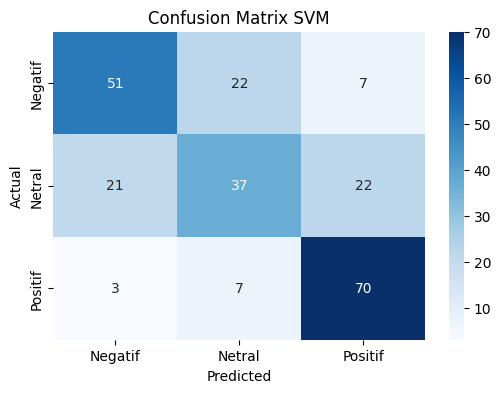

In [51]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negatif','Netral','Positif'],
    yticklabels=['Negatif','Netral','Positif']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix SVM')
plt.show()

## 10. Penyimpanan Model

In [52]:
# Simpan Model

import joblib

joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

## 11. Pengujian Model

In [57]:
# Review Positif
review_baru = [
    "Aplikasi sangat bagus dan membantu proses belanja secara online"
]

review_tfidf = tfidf.transform(review_baru)

prediksi = svm_model.predict(review_tfidf)

print("Review :", review_baru[0])
print("Sentimen :", prediksi[0])

Review : Aplikasi jelek
Sentimen : Negatif


In [59]:
# Review Negatif
review_baru = [
    "Ga mau belanja disini lagi karena pelayana CS nya lama"
]

review_tfidf = tfidf.transform(review_baru)

prediksi = svm_model.predict(review_tfidf)

print("Review :", review_baru[0])
print("Sentimen :", prediksi[0])

Review : Ga mau belanja disini lagi karena pelayana CS nya lama
Sentimen : Negatif
